<a href="https://colab.research.google.com/github/andyotani/andyotani-PCVK_Ganjil_26-27/blob/main/Jobsheet03/JS03_pcvk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Modul 3 – Operasi Citra Sederhana**

**PRAKTIKUM**

D1. Operasi Citra Sederhana

1. Buka https://colab.research.google.com/, pilih tab Github dan pastikan repository yang
terpilih ada repository yang sama dengan praktikum pada minggu pertama dan kedua.
Lanjutkan dengan membuat notebook baru dan ubah nama file menjadi “JS03_pcvk.ipynb”.
Perhatian: Jangan lupa untuk menyimpan salinan ke Github setelah melakukan
perubahan / ketika Anda sudah selesai melakukan praktikum.
2. Akses folder images pada Google Drive Anda dengan kode berikut:



In [26]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import math
import glob
import os

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [27]:
base_path = '/content/drive/MyDrive/PCVK/'

In [29]:
def show_image(title, image, cmap=None):
    plt.figure(figsize=(6, 5))

    if cmap:
        plt.imshow(image, cmap=cmap)
    else:
        plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))

    plt.title(title)
    plt.axis('off')
    plt.show()

Ikuti alur autorisasinya hingga muncul pesan: “Mounted at /content/drive”.

3. Melakukan transformasi linier brightness dengan memasukkan nilai konstanta tertentu
dan menghasilkan warna. Seperti yang telah dibahas pada ulasan teori, formula untuk
melakukan transformasi linier brightness adalah sebagai berikut:
 **g(x, y) = f(x, y) + b
dimana g(x,y)** adalah nilai pixel setelah transformasi, f(x,y)
adalah nilai pixel asli, dan b
adalah nilai brightness.
Tuliskan potongan kode berikut untuk mengimplementasikan linier brightness pada
google colab:

Linear Brightness pada citra
----------------------------
Masukkan nilai brightness: 30


/tmp/ipykernel_4503/3847877912.py:18: RuntimeWarning: overflow encountered in scalar add
  original[y, x, c] + brightness,


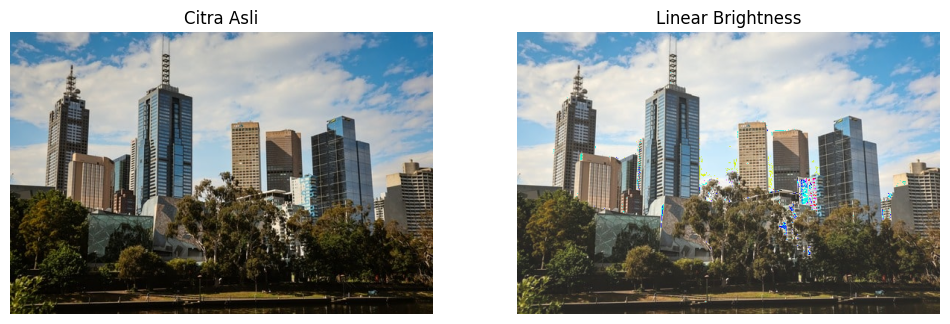

In [32]:
print('Linear Brightness pada citra')
print('----------------------------')

try:
    brightness = int(input('Masukkan nilai brightness: '))

    original = cv.imread(base_path + 'houses.jpg')

    if original is None:
        print('Gambar tidak ditemukan')
    else:
        bright_image = np.zeros(original.shape, original.dtype)

        for y in range(original.shape[0]):
            for x in range(original.shape[1]):
                for c in range(original.shape[2]):
                    bright_image[y, x, c] = np.clip(
                        original[y, x, c] + brightness,
                        0,
                        255
                    )

        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
        plt.title('Citra Asli')
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(cv.cvtColor(bright_image, cv.COLOR_BGR2RGB))
        plt.title('Linear Brightness')
        plt.axis('off')

        plt.show()

except ValueError:
    print('Error, not a number')

Dari potongan kode di atas dapat dilihat bahwa ketika dijalankan, system akan
menampilkan text field untuk memasukkan konstanta nilai brightness yang diinginkan,
dan akan disimpan pada variabel brightness. Kemudian ditentukan citra pada drive yang
akan diolah dan ditampung di variabel original. Tahap selanjutnya adalah mengakses
pixel citra masukan dengan 3 perulangan. Perulangan pertama dilakukan pada shape[0]
untuk tinggi citra, perulangan kedua dilakukan pada shape[1] untuk lebar citra, dan
perulangan ketiga dilakukan pada shape[2] yang merupakan channel warna pada citra.
Setelah melakukan 3 perulangan, dilakukan transformasi linier brightness dengan cara
menambahkan nilai brightness pada citra masukan. Contoh hasil dari kode program di
atas adalah sebagai berikut.

TUGAS PRAKTIKUM

1. Implementasi Inverse Citra
       <p> Rumus modul:

  $$ g(x,y)=255-f(x,y) $$

       

   Inverse menghasilkan citra negatif dengan membalik nilai pixel.

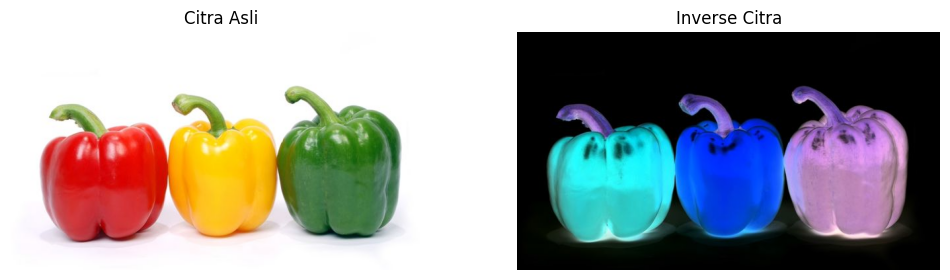

In [5]:
original = cv.imread(base_path + 'paprika.jpg')

inverse = 255 - original

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(inverse, cv.COLOR_BGR2RGB))
plt.title('Inverse Citra')
plt.axis('off')

plt.show()

### Analisis laporan
Operasi inverse citra dilakukan dengan mengurangi setiap nilai pixel terhadap 255. Pixel yang memiliki nilai terang akan berubah menjadi gelap, sedangkan pixel gelap akan berubah menjadi terang. Hasilnya adalah citra negatif dari gambar asli.

2.

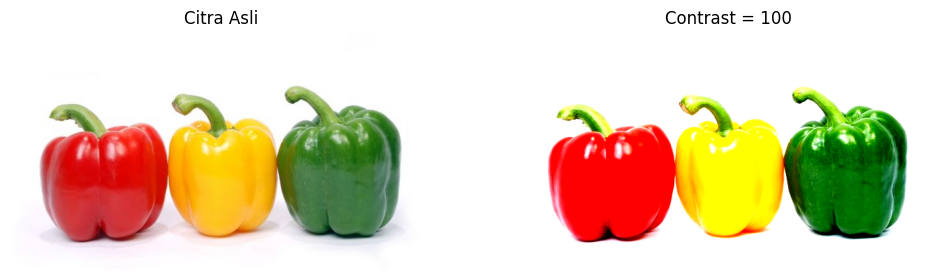

In [6]:
original = cv.imread(base_path + 'paprika.jpg')

contrast_value = 100

factor = (259 * (contrast_value + 255)) / (255 * (259 - contrast_value))

contrast_image = np.zeros_like(original)

for i in range(original.shape[0]):
    for j in range(original.shape[1]):
        for k in range(original.shape[2]):
            new_value = factor * (int(original[i, j, k]) - 128) + 128
            contrast_image[i, j, k] = np.clip(new_value, 0, 255)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(contrast_image, cv.COLOR_BGR2RGB))
plt.title('Contrast = 100')
plt.axis('off')

plt.show()

3.

/tmp/ipykernel_4503/3494760679.py:5: RuntimeWarning: overflow encountered in scalar add
  c = 255 / np.log(1 + np.max(gray))
/tmp/ipykernel_4503/3494760679.py:5: RuntimeWarning: divide by zero encountered in log
  c = 255 / np.log(1 + np.max(gray))


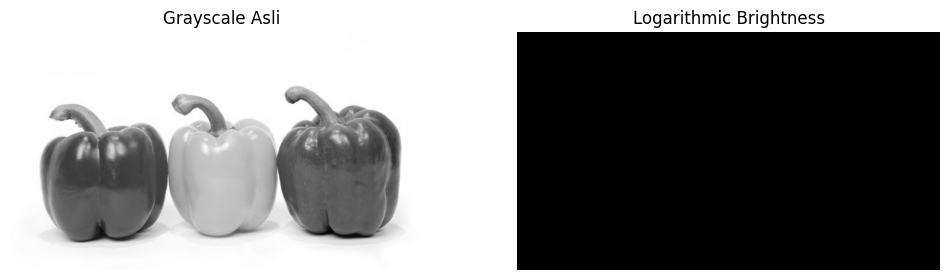

In [8]:
original = cv.imread(base_path + 'paprika.jpg')

gray = cv.cvtColor(original, cv.COLOR_BGR2GRAY)

c = 255 / np.log(1 + np.max(gray))

log_image = c * (np.log(gray.astype(np.float32) + 1))

log_image = np.uint8(np.clip(log_image, 0, 255))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title('Grayscale Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(log_image, cmap='gray')
plt.title('Logarithmic Brightness')
plt.axis('off')

plt.show()

4.

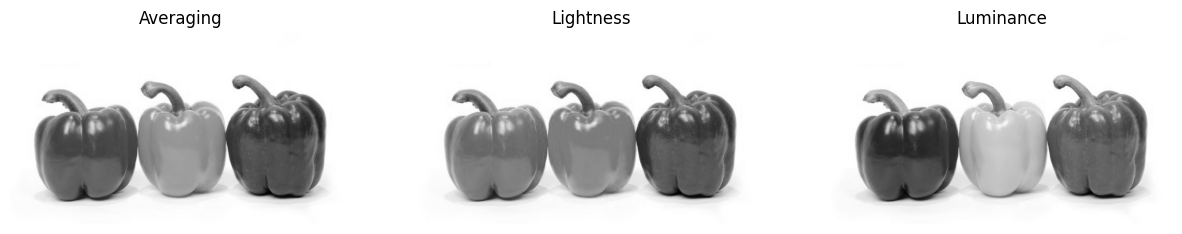

In [10]:
original = cv.imread(base_path + 'paprika.jpg')

# OpenCV menggunakan urutan BGR
B, G, R = cv.split(original)

# Averaging
gray_averaging = ((R.astype(np.float32) +
                   G.astype(np.float32) +
                   B.astype(np.float32)) / 3).astype(np.uint8)

# Lightness
gray_lightness = (
    (np.maximum.reduce([R, G, B]).astype(np.float32) +
     np.minimum.reduce([R, G, B]).astype(np.float32)) / 2
).astype(np.uint8)

# Luminance
gray_luminance = (
    0.21 * R.astype(np.float32) +
    0.72 * G.astype(np.float32) +
    0.07 * B.astype(np.float32)
).astype(np.uint8)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(gray_averaging, cmap='gray')
plt.title('Averaging')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(gray_lightness, cmap='gray')
plt.title('Lightness')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(gray_luminance, cmap='gray')
plt.title('Luminance')
plt.axis('off')

plt.show()

5.

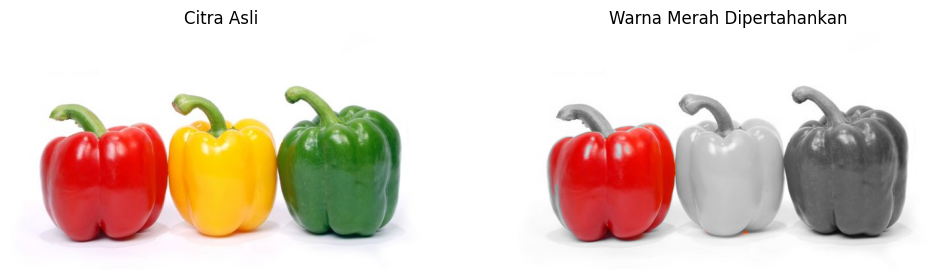

In [12]:
original = cv.imread(base_path + 'paprika.jpg')

hsv = cv.cvtColor(original, cv.COLOR_BGR2HSV)

# Rentang warna merah
lower_red1 = np.array([0, 100, 50])
upper_red1 = np.array([10, 255, 255])

lower_red2 = np.array([170, 100, 50])
upper_red2 = np.array([180, 255, 255])

mask1 = cv.inRange(hsv, lower_red1, upper_red1)
mask2 = cv.inRange(hsv, lower_red2, upper_red2)

mask = mask1 | mask2

gray = cv.cvtColor(original, cv.COLOR_BGR2GRAY)
gray_bgr = cv.cvtColor(gray, cv.COLOR_GRAY2BGR)

result = np.where(mask[:, :, None] > 0, original, gray_bgr)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
plt.title('Warna Merah Dipertahankan')
plt.axis('off')

plt.show()

6.

Gamma Correction pada citra
---------------------------
Masukkan nilai Gamma: 100


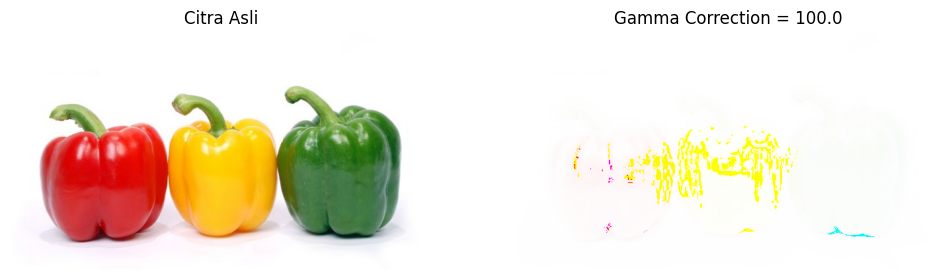

In [13]:
original = cv.imread(base_path + 'paprika.jpg')

print('Gamma Correction pada citra')
print('---------------------------')

try:
    gamma = float(input('Masukkan nilai Gamma: '))

    if gamma <= 0:
        print('Gamma harus lebih besar dari 0')
    else:
        gamma_image = 255 * (
            original.astype(np.float32) / 255
        ) ** (1 / gamma)

        gamma_image = np.uint8(np.clip(gamma_image, 0, 255))

        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
        plt.title('Citra Asli')
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(cv.cvtColor(gamma_image, cv.COLOR_BGR2RGB))
        plt.title(f'Gamma Correction = {gamma}')
        plt.axis('off')

        plt.show()

except ValueError:
    print('Error, not a number')

7.

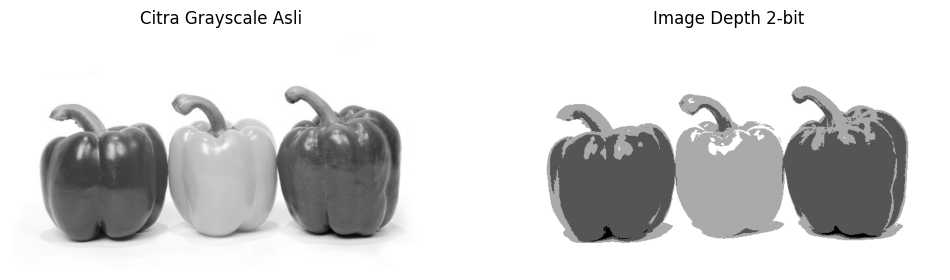

In [14]:
bit_depth = 2

original = cv.imread(
    base_path + 'paprika.jpg',
    cv.IMREAD_GRAYSCALE
)

level = 255 / (pow(2, bit_depth) - 1)

depth_image = np.zeros(original.shape, original.dtype)

for i in range(original.shape[0]):
    for j in range(original.shape[1]):
        depth_image[i, j] = round(
            round(original[i, j] / level) * level
        )

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(original, cmap='gray')
plt.title('Citra Grayscale Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(depth_image, cmap='gray')
plt.title(f'Image Depth {bit_depth}-bit')
plt.axis('off')

plt.show()

8.

In [19]:
original = cv.imread(base_path + 'galaxy.jpg')

noise_images = []

for img_path in glob.glob(base_path + 'noises/*.jpg'):
    img = cv.imread(img_path)
    noise_images.append(img)

print('Jumlah citra noise:', len(noise_images))

Jumlah citra noise: 0


In [20]:
def PSNR(img1, img2):
    mse = np.mean((img1.astype(np.float32) - img2.astype(np.float32)) ** 2)

    if mse == 0:
        return 100

    max_pixel = 255.0
    return 20 * math.log10(max_pixel / math.sqrt(mse))

In [21]:
def average_images(images):
    stack = np.stack(images).astype(np.float32)
    avg = np.mean(stack, axis=0)
    return np.uint8(np.clip(avg, 0, 255))

In [22]:
jumlah_citra = [10, 20, 40, 80, 100]
hasil_psnr = []

for jumlah in jumlah_citra:
    selected_images = noise_images[:jumlah]

    avg_image = average_images(selected_images)

    psnr_value = PSNR(original, avg_image)
    hasil_psnr.append(psnr_value)

    print(f'{jumlah} citra = {psnr_value:.2f} dB')

ValueError: need at least one array to stack

In [23]:
plt.figure(figsize=(15, 8))

for index, jumlah in enumerate(jumlah_citra):
    avg_image = average_images(noise_images[:jumlah])

    plt.subplot(2, 3, index + 1)
    plt.imshow(cv.cvtColor(avg_image, cv.COLOR_BGR2RGB))
    plt.title(f'Average {jumlah} citra')
    plt.axis('off')

plt.show()

ValueError: need at least one array to stack

<Figure size 1500x800 with 0 Axes>

9.

In [25]:
original = cv.imread(base_path + 'couple.tiff')

gray = cv.cvtColor(original, cv.COLOR_BGR2GRAY)

_, mask1 = cv.threshold(gray, 127, 255, cv.THRESH_BINARY)

# Mask kedua menggunakan threshold berbeda
_, mask2 = cv.threshold(gray, 200, 255, cv.THRESH_BINARY)

# Operator logika
not_mask = cv.bitwise_not(mask1)
or_mask = cv.bitwise_or(mask1, mask2)
and_mask = cv.bitwise_and(mask1, mask2)

nand_mask = cv.bitwise_not(and_mask)
xor_mask = cv.bitwise_xor(mask1, mask2)

results = [
    ('NOT', not_mask),
    ('OR', or_mask),
    ('AND', and_mask),
    ('NAND', nand_mask),
    ('XOR', xor_mask)
]

plt.figure(figsize=(15, 8))

for i, (title, image) in enumerate(results):
    plt.subplot(2, 3, i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(title)
    plt.axis('off')

plt.show()

error: OpenCV(5.0.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


10.

In [ ]:
night = cv.imread(base_path + 'night.jpg')

gamma = 2.5

gamma_image = 255 * (
    night.astype(np.float32) / 255
) ** (1 / gamma)

gamma_image = np.uint8(np.clip(gamma_image, 0, 255))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(night, cv.COLOR_BGR2RGB))
plt.title('Foto Malam Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(gamma_image, cv.COLOR_BGR2RGB))
plt.title('Setelah Gamma Correction')
plt.axis('off')

plt.show()

11.


In [ ]:
crayfish = cv.imread(base_path + 'crayfish.jpg')

# Gamma correction
gamma = 1.8

gamma_image = 255 * (
    crayfish.astype(np.float32) / 255
) ** (1 / gamma)

gamma_image = np.uint8(np.clip(gamma_image, 0, 255))

# Contrast enhancement menggunakan CLAHE pada grayscale
gray = cv.cvtColor(gamma_image, cv.COLOR_BGR2GRAY)

clahe = cv.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

enhanced_gray = clahe.apply(gray)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(crayfish, cv.COLOR_BGR2RGB))
plt.title('Before')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(enhanced_gray, cmap='gray')
plt.title('After Enhancement')
plt.axis('off')

plt.show()